In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\6AN"
analytical_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\semi-analytic_100MHz"
postprocess_folder = os.path.join(base_folder, "postprocess")

In [9]:
def receiver_line_plot(datasets, quantities, postprocess_folder, fname, orientation='Endfire',
                    suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.5

    # colors = ['#000000', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3"]

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Analytical Solution': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'Analytical Solution'
        },
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    # "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        # '--',         # dashed
        '-.',         # dash-dot
        (0, (1, 1)),  # dense dots
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        ':',          # dotted
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot analytical curves
        for src, style in fixed_styles.items():
            try:
                ds = next(d for d in datasets if d[6] == src)
            except StopIteration:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            ln, = plot_fn(x, y,
                          color=style['color'],
                          linestyle=style['linestyle'],
                          linewidth=style['linewidth'],
                          zorder=style['zorder'],
                            label=style['label'])
            ln.set_path_effects([
                pe.Stroke(linewidth=style['linewidth']+2, foreground='white'),
                pe.Normal()
            ])

        # Plot variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            plot_fn(x, y,
                    label=src,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])

        # Grid, labels, legend
        ax.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax.set_title(title, fontsize=font_label, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 3:
            ax.legend(fontsize=font_legend, loc='lower right')

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    print(f"Saved plot to {os.path.join(postprocess_folder, fname)}")
    plt.show()

def compute_errors(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

def receiver_line_error_plot(datasets, reference_dataset, quantities, postprocess_folder, fname, orientation='Endfire',
                             suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.5

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Evert': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'Analytical Solution'
        },
        'empymod - 2001 DLF': {
            'color':    '#4B2E05',  # brown
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'empymod - 2001 DLF'
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        '-.',         # dash-dot
        (0, (1, 1)),  # dense dots
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        ':',          # dotted
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }
    # compute global amplitude normalized error limits
    amp_errs = []
    for ds in datasets:
        y_src = ds[0]
        y_ref = reference_dataset[0]
        with np.errstate(divide='ignore', invalid='ignore'):
            err = np.abs(y_src - y_ref)/np.abs(y_ref)
            err[~np.isfinite(err)] = np.nan
        amp_errs.append(err)
    amp_min, amp_max = np.nanmin(np.hstack(amp_errs)), np.nanmax(np.hstack(amp_errs))

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot errors for variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            ref_data = reference_dataset[j]
            elfe_data = ds[j]
            if j in [0, 2, 3]:
                with np.errstate(divide='ignore', invalid='ignore'):
                    err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                    err[~np.isfinite(err)] = np.nan
                ax.set_title(f"Normalized Error in {title}", fontsize=font_label, fontweight='bold')
                print(f"Max error in {title}: {np.nanmax(err):.2e}")
            else:
                err = elfe_data - ref_data
                ax.set_title(f"Error in {title}", fontsize=font_label, fontweight='bold')
                print(f"Max error in {title}: {np.nanmax(np.abs(err)):.2e}")
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j != 1 else ax.plot
            plot_fn(x, err,
                    label=f"{src}",
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, which='both' if j != 1 else 'major', linestyle='--', linewidth=0.5)
        ax.set_ylabel('Error', fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 1:
            ax.legend(fontsize=font_legend, loc='upper right')
        if j in [0, 2, 3]:  # real and imag clip to amplitude error bounds
            ax.set_ylim(amp_min, amp_max)
        else:
            ax.set_ylim(-0.5, 0.5)

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    plt.show()

def plot_error_stats(
    error_stats,
    pml_thickness_list,
    xticklabels_lambda,
    quantities,
    title_list,
    postprocess_folder,
    fname='ft.png',
    font_label=15,
    font_tick=13,
    font_legend=13,
    font_suptitle=18,
    mark_size=6,
    suptitle=r"Error Statistics of Endfire Ex Field vs PML Thickness \(d\)",
    xlabel=r'$d = \lambda / f_t$',
    loc='best',
    legend_pos=0,
    use_logx=False
):
    # —— style setup —— #
    colors = ['#1b9e77', '#d95f02']
    plt.rcParams['axes.prop_cycle'] = cycler('color', colors)
    plt.rcParams.update({
        'font.family':       'sans-serif',
        'font.size':         font_tick,
        'axes.facecolor':    'white',
        'axes.edgecolor':    'black',
        'axes.linewidth':    1.0,
        'axes.grid':         True,
        'grid.linestyle':    '--',
        'grid.linewidth':    0.5,
        'xtick.direction':   'out',
        'ytick.direction':   'out',
        'xtick.major.size':  5,
        'ytick.major.size':  5,
        'legend.frameon':    True,
        'axes.titleweight':  'bold',
    })

    marker_mean = 'o'
    marker_max  = 's'
    x_vals = pml_thickness_list

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for j, ax in enumerate(axes):
        means = [error_stats[i][j][0] for i in range(len(error_stats))]
        stds  = [error_stats[i][j][1] for i in range(len(error_stats))]
        maxs  = [error_stats[i][j][2] for i in range(len(error_stats))]

        # plot mean + std
        ax.plot(
            x_vals, means,
            '-', linewidth=2,
            marker=marker_mean, markersize=mark_size,
            label='Mean'
        )
        ax.fill_between(
            x_vals,
            np.array(means) - np.array(stds),
            np.array(means) + np.array(stds),
            alpha=0.3, label='±1 Std Dev'
        )

        # plot max (except for phase subplot)
        if j != 1:
            ax.plot(
                x_vals, maxs,
                '--', linewidth=2,
                marker=marker_max, markersize=mark_size,
                label='Max'
            )

        # titles & labels
        ax.set_title(title_list[j], fontsize=font_label)
        if j >= 2:
            ax.set_xlabel(xlabel, fontsize=font_label)
        ax.set_ylabel('Error', fontsize=font_label)

        # legend only on the first subplot by default
        if j == legend_pos:
            ax.legend(loc=loc, fontsize=font_legend)

        # custom x-ticks & optional log scale
        if use_logx:
            ax.set_xscale('log')
            ax.xaxis.set_major_locator(FixedLocator(x_vals))
            ax.xaxis.set_major_formatter(FixedFormatter(xticklabels_lambda))
        else:
            ax.set_xticks(x_vals)
            ax.set_xticklabels(xticklabels_lambda, fontsize=font_tick)

        ax.tick_params(axis='y', labelsize=font_tick)

    # super‐title, save & show
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    out_path = os.path.join(postprocess_folder, fname)
    plt.savefig(out_path, dpi=300)
    plt.show()


## Anomaly 20

10090.6452416896
Saved plot to F:\Projects\EMGeoInversion\Tests_Thesis\6AN\postprocess\AnTL.png


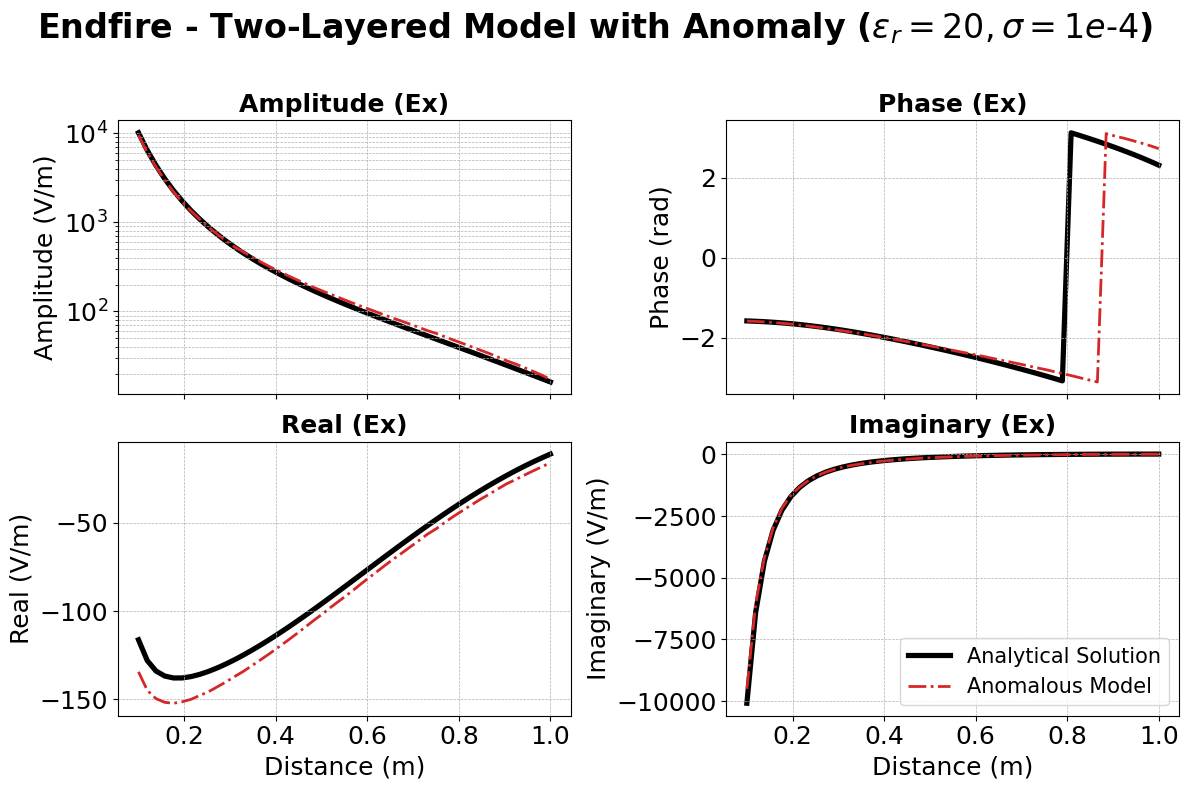

In [10]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_4_9_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)
evert_max = abs_endfire.max()
print(abs_endfire.max())

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Analytical Solution'),
]


quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]


electric_file = os.path.join(base_folder, "out_AnAir", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1]

labels = [
    r'Anomalous Model',
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [48] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4

receiver_line_plot(
    datasets=datasets_4,
    quantities=quantities,
    postprocess_folder=postprocess_folder,
    fname='AnTL.png',
    orientation='Endfire',
    suptitle=f"Endfire - Two-Layered Model with Anomaly ($\\varepsilon_r=20, \\sigma=1e\\text{{-}}4$)",
)